# 📊 Notebook 01 – Exploratory Data Analysis

**Objective:** Deeply understand the structure, quality, and statistical properties of the stock price dataset before any modelling.

---
### Table of Contents
1. Environment Setup
2. Data Loading & Inspection
3. Data Quality Assessment
4. Price History Visualisation
5. Rolling Statistics & Volatility
6. Return Distribution Analysis
7. Correlation Analysis
8. Interactive Charts
9. Key Insights Summary


In [1]:
# ── 1. Environment Setup ─────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display

from data_preprocessing import preprocess, dataset_summary
from utils import (
    ensure_sample_data, set_plot_style,
    plot_price_history, plot_rolling_stats,
    plot_correlation_heatmap, plot_return_distribution,
    plot_bollinger_bands_interactive,
)

set_plot_style()
print('✅ Environment ready.')


✅ Environment ready.


In [2]:
# ── 2. Data Loading & Inspection ─────────────────────────────────────────────
# If you have your own CSV, change this path:
RAW_PATH  = '../data/raw/stock_data.csv'
SAVE_PATH = '../data/processed/stock_data_clean.csv'

# Generate demo data if no file exists
ensure_sample_data(RAW_PATH)

# Load & clean
df = preprocess(RAW_PATH, save_path=SAVE_PATH)

print('\n📋 First 5 rows:')
display(df.head())

print('\n📐 Shape:', df.shape)
print('\n🔢 Data types:')
display(df.dtypes)


INFO | Sample data generated → ../data/raw/stock_data.csv
INFO | Loading raw data from: ../data/raw/stock_data.csv
INFO | Raw shape: (1000, 7)
INFO | Columns after normalization: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker']
INFO | Date range: 2019-01-01 00:00:00 → 2022-10-31 00:00:00
INFO | Missing value handling: 0 rows dropped.
INFO | Removed 0 duplicate rows.
INFO | Preprocessing complete. Final shape: (1000, 11)
INFO | Cleaned data saved to: ../data/processed/stock_data_clean.csv



📋 First 5 rows:


,Date,Open,High,Low,Close,Volume,Ticker,Daily_Return,HL_Spread,OC_Spread,Log_Return
0,2019-01-01,100.00,101.48,100.43,100.78,8185115,DEMO,NaN,1.05,0.78,NaN
1,2019-01-02,100.78,101.06,100.52,100.60,3585181,DEMO,-0.001786,0.54,-0.18,-0.001788
2,2019-01-03,100.60,101.63,101.20,101.60,8981512,DEMO,0.009940,0.43,1.00,0.009891
3,2019-01-04,101.60,104.29,103.80,103.96,3269798,DEMO,0.023228,0.49,2.36,0.022963
4,2019-01-07,103.96,103.98,102.64,103.62,5181726,DEMO,-0.003270,1.34,-0.34,-0.003276



📐 Shape: (1000, 11)

🔢 Data types:


Date            datetime64[ns]
Open                   float64
High                   float64
Low                    float64
Close                  float64
Volume                   int64
Ticker                  object
Daily_Return           float64
HL_Spread              float64
OC_Spread              float64
Log_Return             float64
dtype: object

In [3]:
# ── 3. Data Quality Assessment ───────────────────────────────────────────────
summary = dataset_summary(df)
print('\n📊 Dataset Summary:')
for k, v in summary.items():
    print(f'  {k:25s}: {v}')

print('\n🔍 Missing values per column:')
missing = df.isnull().sum()
display(missing[missing > 0] if missing.any() else pd.Series({'All columns': 'No missing values ✅'}))

print('\n📈 Descriptive Statistics:')
display(df[['Open','High','Low','Close','Volume','Daily_Return']].describe().round(4))



📊 Dataset Summary:
  rows                     : 1000
  columns                  : 11
  date_start               : 2019-01-01 00:00:00
  date_end                 : 2022-10-31 00:00:00
  trading_days             : 1000
  missing_values           : 2
  close_min                : 83.44
  close_max                : 182.24
  close_mean               : 111.37080999999999
  avg_daily_volume         : 5493810.533

🔍 Missing values per column:


Daily_Return    1
Log_Return      1
dtype: int64


📈 Descriptive Statistics:


,Open,High,Low,Close,Volume,Daily_Return
count,1000.0000,1000.0000,1000.0000,1000.0000,1.000000e+03,999.0000
mean,111.3088,111.8106,110.9326,111.3708,5.493811e+06,0.0006
std,21.4613,21.6017,21.4301,21.5180,2.621948e+06,0.0147
min,83.4400,83.6800,82.9400,83.4400,1.021650e+06,-0.0483
25%,98.1600,98.5425,97.7975,98.1600,3.201014e+06,-0.0094
50%,105.5650,105.9350,105.2250,105.5700,5.414625e+06,0.0006
75%,117.4900,117.9700,117.1650,117.4975,7.844375e+06,0.0100
max,182.2400,182.3800,181.7300,182.2400,9.992719e+06,0.0581


INFO | Saved: outputs/plots\price_history.png


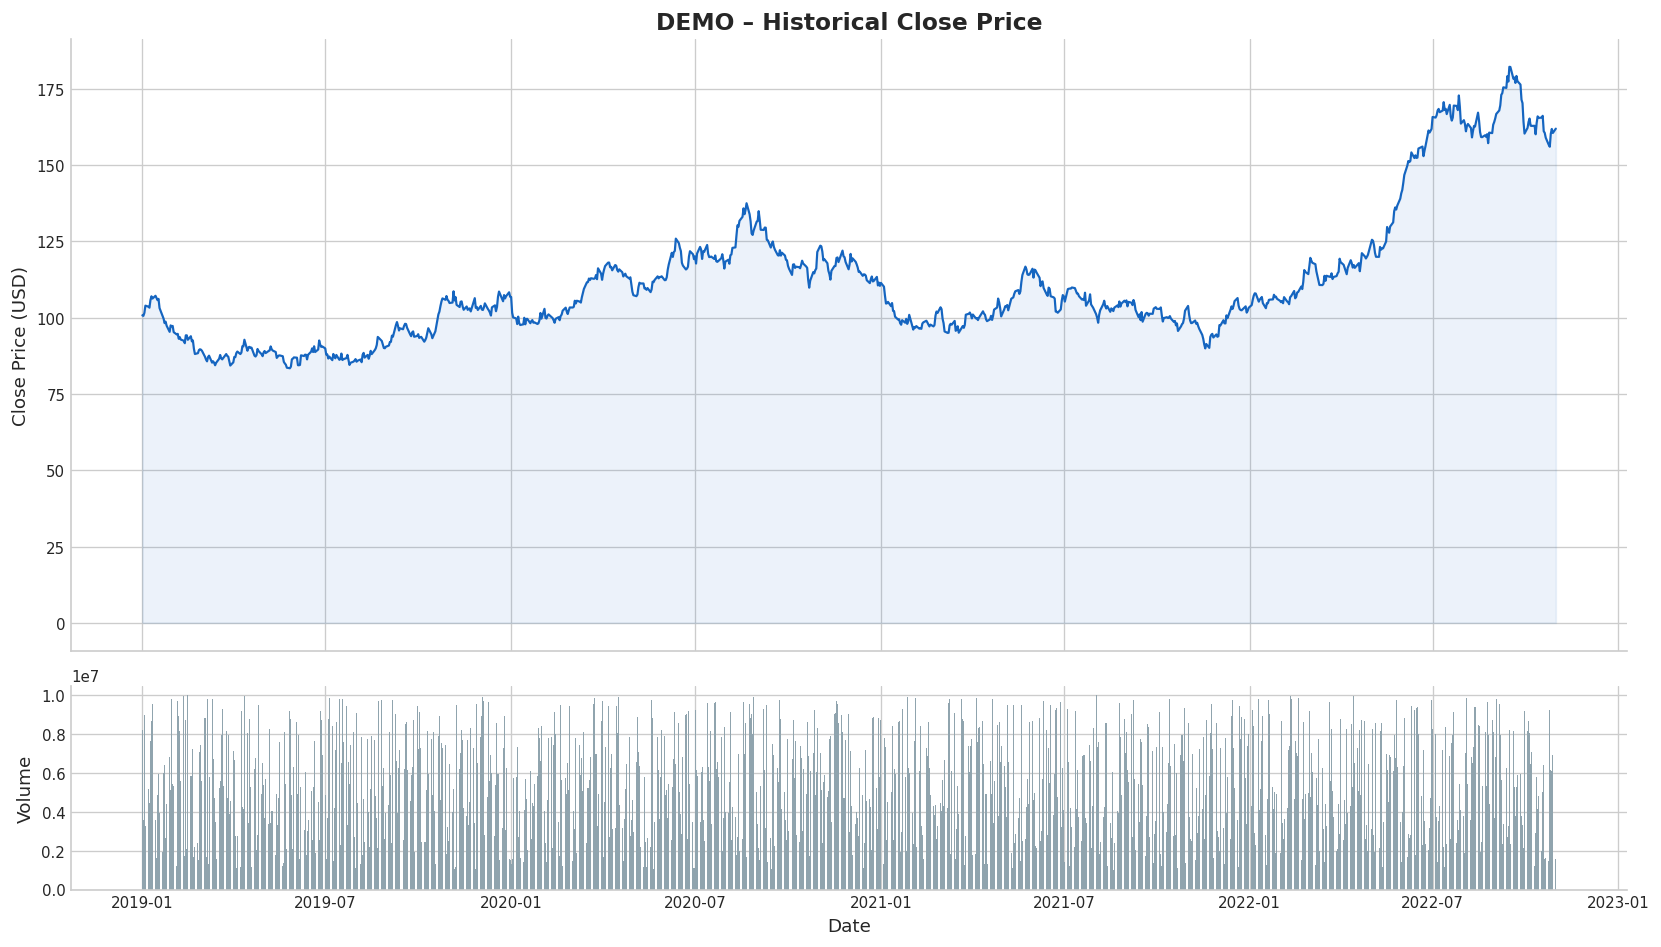


💡 Price ranged from $83.44 to $182.24
   Overall return: 60.7%


In [4]:
# ── 4. Price History Visualisation ───────────────────────────────────────────
# Determine ticker
ticker = df['Ticker'].iloc[0] if 'Ticker' in df.columns else 'Stock'

# Save to outputs/plots/
plot_price_history(df, col='Close', ticker=ticker, save=True)

# Also display inline
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
axes[0].plot(df['Date'], df['Close'], color='#1565C0', linewidth=1.3)
axes[0].fill_between(df['Date'], df['Close'], alpha=0.08, color='#1565C0')
axes[0].set_title(f'{ticker} – Historical Close Price', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Close Price (USD)')

axes[1].bar(df['Date'], df['Volume'], color='#90A4AE', width=1)
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

print(f"\n💡 Price ranged from ${df['Close'].min():.2f} to ${df['Close'].max():.2f}")
print(f"   Overall return: {(df['Close'].iloc[-1]/df['Close'].iloc[0] - 1)*100:.1f}%")


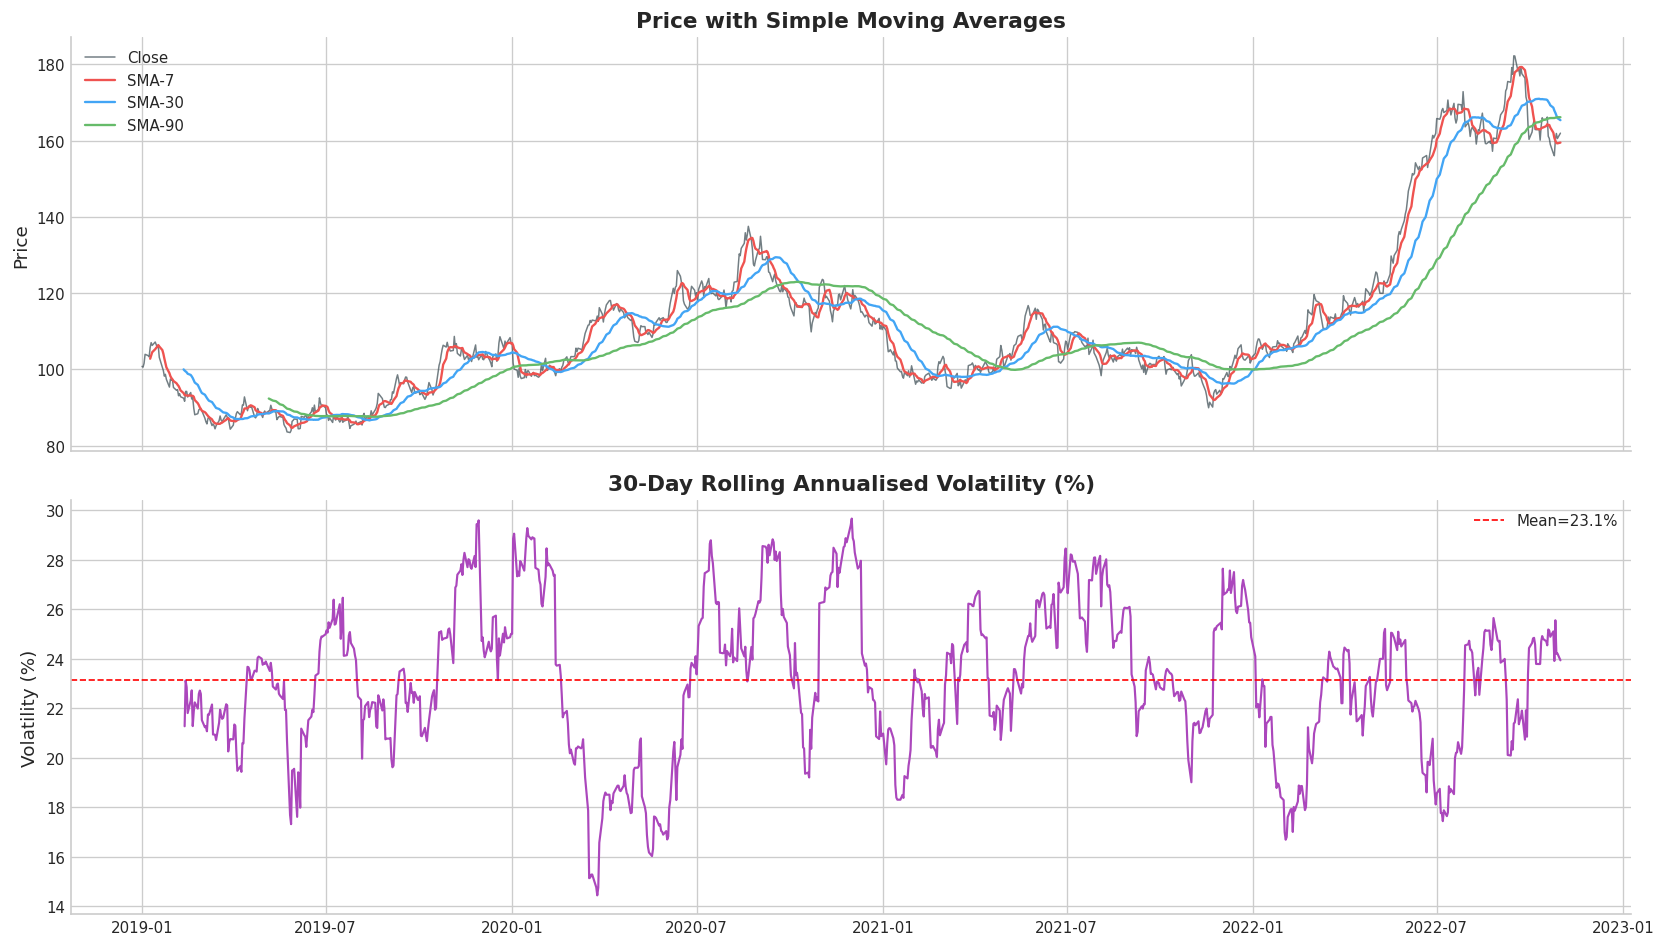


💡 Average annualised volatility: 23.1%
   Peak volatility period: 2020-12-01


In [5]:
# ── 5. Rolling Statistics & Volatility ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(df['Date'], df['Close'], label='Close', color='#37474F', linewidth=0.9, alpha=0.7)
for window, color in zip([7, 30, 90], ['#EF5350', '#42A5F5', '#66BB6A']):
    ax1.plot(df['Date'], df['Close'].rolling(window).mean(),
             label=f'SMA-{window}', color=color, linewidth=1.4)
ax1.set_title('Price with Simple Moving Averages', fontweight='bold')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')

# Rolling volatility (annualised)
vol_30 = df['Daily_Return'].rolling(30).std() * np.sqrt(252) * 100
ax2.plot(df['Date'], vol_30, color='#AB47BC', linewidth=1.3)
ax2.axhline(vol_30.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean={vol_30.mean():.1f}%')
ax2.set_title('30-Day Rolling Annualised Volatility (%)', fontweight='bold')
ax2.set_ylabel('Volatility (%)')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n💡 Average annualised volatility: {vol_30.mean():.1f}%")
print(f"   Peak volatility period: {df.loc[vol_30.idxmax(), 'Date'].date()}")


INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


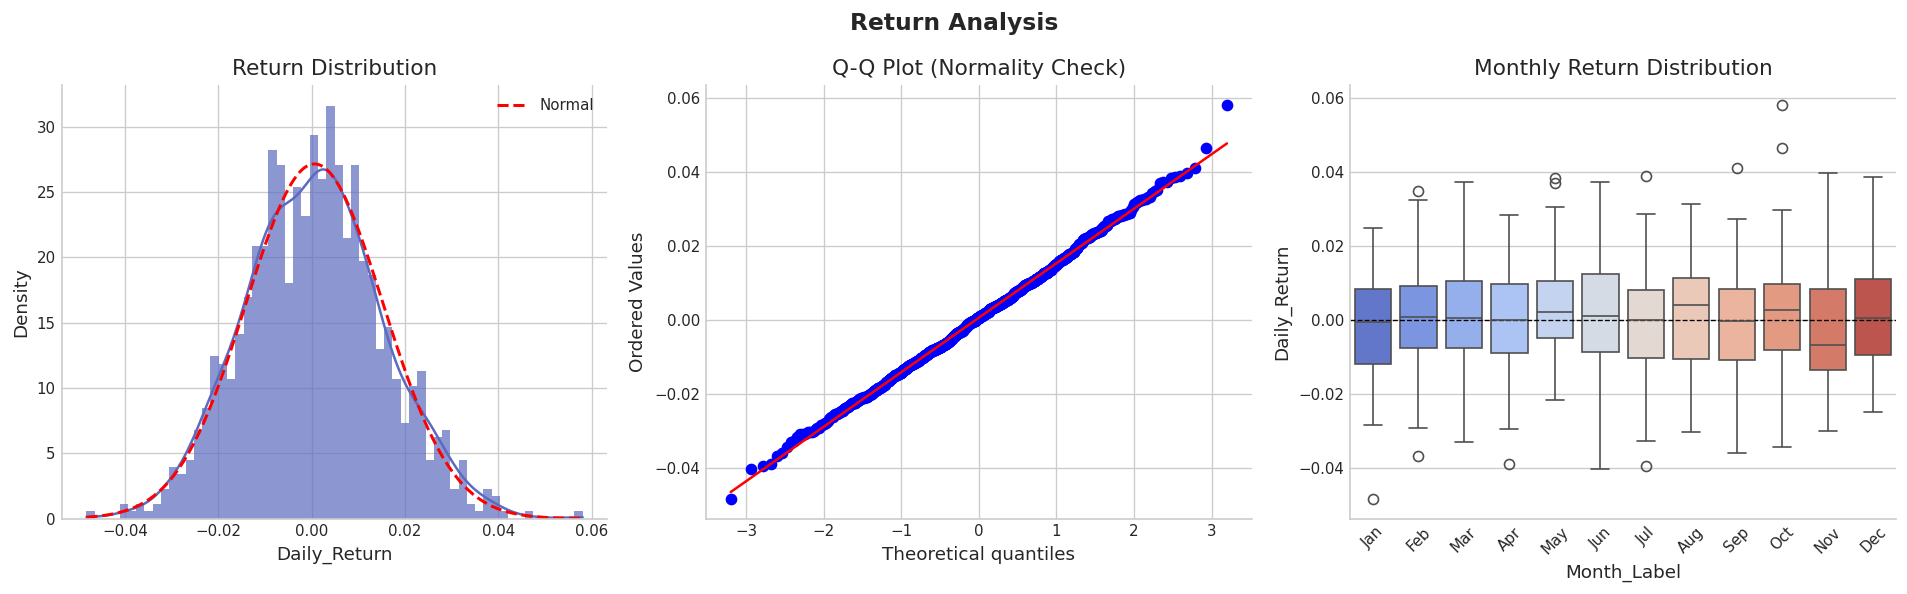


📊 Return Statistics:
   Mean daily return : 0.058%
   Std  daily return : 1.469%
   Skewness          : 0.118
   Kurtosis (excess) : 0.071
   Shapiro-Wilk p    : 0.2761 (Normal ✅)


In [6]:
# ── 6. Return Distribution Analysis ──────────────────────────────────────────
from scipy.stats import norm, shapiro

returns = df['Daily_Return'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram + KDE
sns.histplot(returns, bins=60, kde=True, stat='density', color='#5C6BC0',
             ax=axes[0], edgecolor='none', alpha=0.7)
x = np.linspace(returns.min(), returns.max(), 200)
axes[0].plot(x, norm.pdf(x, returns.mean(), returns.std()), 'r--', lw=1.8, label='Normal')
axes[0].set_title('Return Distribution')
axes[0].legend()

# QQ-plot
from scipy.stats import probplot
probplot(returns, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)')
axes[1].get_lines()[1].set_color('red')

# Monthly returns box
df['Month_Label'] = df['Date'].dt.strftime('%b')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_data = df[df['Month_Label'].isin(month_order)]
sns.boxplot(data=month_data, x='Month_Label', y='Daily_Return',
            order=month_order, ax=axes[2], palette='coolwarm')
axes[2].set_title('Monthly Return Distribution')
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Return Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

_, p_val = shapiro(returns.sample(min(500, len(returns)), random_state=42))
print(f"\n📊 Return Statistics:")
print(f"   Mean daily return : {returns.mean()*100:.3f}%")
print(f"   Std  daily return : {returns.std()*100:.3f}%")
print(f"   Skewness          : {returns.skew():.3f}")
print(f"   Kurtosis (excess) : {returns.kurtosis():.3f}")
print(f"   Shapiro-Wilk p    : {p_val:.4f} ({'Non-normal ⚠' if p_val < 0.05 else 'Normal ✅'})")


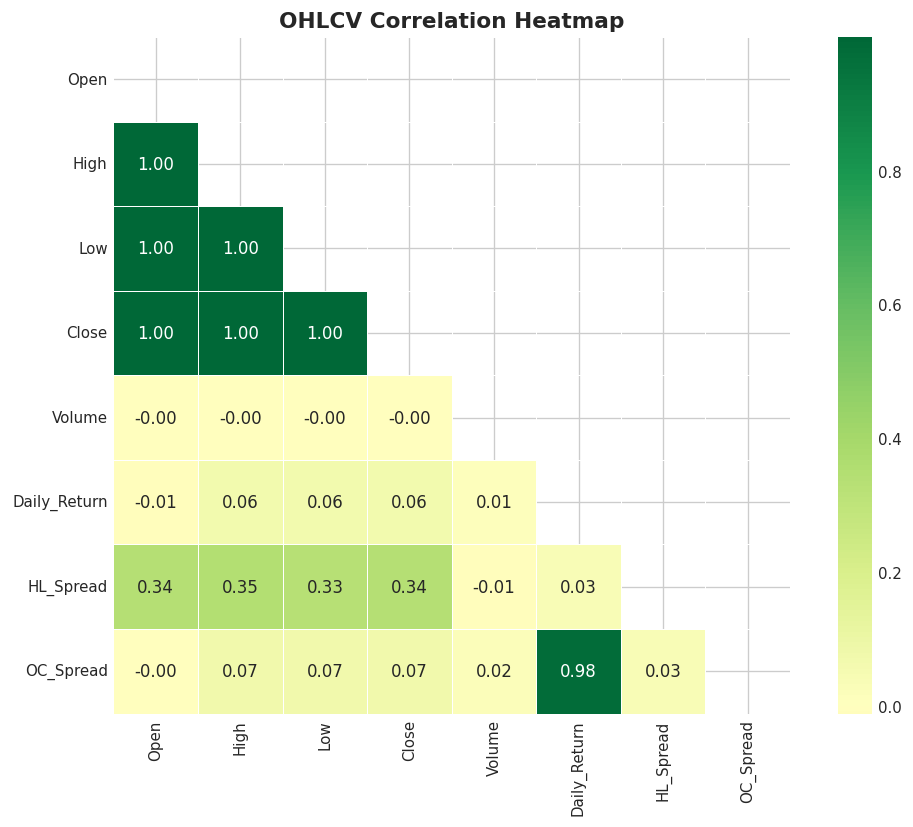


💡 Key correlations:
   Close vs Open    : +0.997
   Close vs High    : +1.000
   Close vs Low     : +1.000
   Close vs Volume  : -0.003


In [7]:
# ── 7. Correlation Analysis ───────────────────────────────────────────────────
ohlcv_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'HL_Spread', 'OC_Spread']
corr = df[ohlcv_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 10}, square=True)
ax.set_title('OHLCV Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Key correlations:")
for col in ['Open', 'High', 'Low', 'Volume']:
    print(f"   Close vs {col:8s}: {corr.loc['Close', col]:+.3f}")


In [8]:
# ── 8. Interactive Charts (Plotly) ────────────────────────────────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    row_heights=[0.75, 0.25],
                    subplot_titles=['Candlestick', 'Volume'])

tail = df.tail(365)
fig.add_trace(go.Candlestick(
    x=tail['Date'], open=tail['Open'], high=tail['High'],
    low=tail['Low'],  close=tail['Close'], name='OHLC'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=tail['Date'], y=tail['Volume'],
    name='Volume', marker_color='#90A4AE'
), row=2, col=1)

fig.update_layout(
    title=f'📈 {ticker} – Last 365 Trading Days',
    xaxis_rangeslider_visible=False,
    template='plotly_white', height=600
)
fig.show()


In [9]:
# ── 9. Key Insights Summary ───────────────────────────────────────────────────
print('═'*60)
print('  KEY INSIGHTS FROM EDA')
print('═'*60)

total_return = (df['Close'].iloc[-1] / df['Close'].iloc[0] - 1) * 100
ann_vol      = df['Daily_Return'].std() * np.sqrt(252) * 100
max_dd_val   = ((df['Close'] / df['Close'].cummax()) - 1).min() * 100
best_day     = df['Daily_Return'].max() * 100
worst_day    = df['Daily_Return'].min() * 100

insights = [
    ('Date range'         , f"{df['Date'].min().date()} → {df['Date'].max().date()}"),
    ('Trading days'       , len(df)),
    ('Total price return' , f"{total_return:+.1f}%"),
    ('Annualised vol.'    , f"{ann_vol:.1f}%"),
    ('Max drawdown'       , f"{max_dd_val:.1f}%"),
    ('Best single day'    , f"{best_day:+.2f}%"),
    ('Worst single day'   , f"{worst_day:+.2f}%"),
    ('Return skewness'    , f"{df['Daily_Return'].skew():.3f} (fat tails noted)"),
]

for label, value in insights:
    print(f'  {label:25s}: {value}')

print('\n  → Next step: Feature Engineering (Notebook 02)')


════════════════════════════════════════════════════════════
  KEY INSIGHTS FROM EDA
════════════════════════════════════════════════════════════
  Date range               : 2019-01-01 → 2022-10-31
  Trading days             : 1000
  Total price return       : +60.7%
  Annualised vol.          : 23.3%
  Max drawdown             : -34.6%
  Best single day          : +5.81%
  Worst single day         : -4.83%
  Return skewness          : 0.118 (fat tails noted)

  → Next step: Feature Engineering (Notebook 02)
